# Phase 1: CNN Error Analysis — Diagnostic Baseline

## Foundational Setup & Diagnostic Analysis

This notebook implements a pure CNN (no attention mechanisms) on FashionMNIST and performs systematic error analysis to identify root causes of class confusion.

| Step | Description | What it does | Import path |
|------|-------------|--------------|-------------|
| 1 | Import Libraries | Load PyTorch, src modules, detect device | --- |
| 2 | Load Dataset | Download FashionMNIST + apply transforms | `src/data_utils.py` |
| 3 | Define CNN | Define DiagnosticCNN (3 conv blocks, GAP, Dropout) | --- |
| 4 | Train Model | Train DiagnosticCNN for 15 epochs, save per-epoch losses | `src/train_utils.py` |
| 5 | Evaluate Model | Per-class TPR, Precision, confusion matrix | `src/eval_utils.py` |
| 6 | ROC & PR Curves | ROC-AUC and PR-AUC scores per class | `src/eval_utils.py`, `src/vis_utils.py` |
| 7 | Save Metrics | Save all metrics as .txt/.md to outputs/error_analysis/ | `src/eval_utils.py` |
| 8 | Per-Class Mean Images | Compute and visualize mean image per class | --- |
| 9 | Difference Maps | Between-class pixel difference maps | --- |
| 10 | Variance Analysis | Intra-class and inter-class variance maps | --- |
| 11 | Confidence Analysis | Correct vs error confidence distributions | --- |
| 12 | Misclassification Analysis | Per-pair error counts and confusion heatmaps | --- |

---


In [ ]:
import os, sys
# Detect project root: look for src/ directory in CWD or parents
def _find_root(marker="src", max_up=3):
    p = os.path.abspath(os.getcwd())
    for _ in range(max_up + 1):
        if os.path.isdir(os.path.join(p, marker)):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.getcwd())
PROJ_ROOT = _find_root()
sys.path.insert(0, PROJ_ROOT)

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader

from src.data_utils import get_fashionmnist_transforms, load_fashionmnist, get_dataloaders

from src.train_utils import train_one_epoch

from src.eval_utils import (
    evaluate_detailed, get_all_probas_and_labels,
    compute_roc_auc_scores, compute_pr_auc_scores)

from src.model_utils import save_model

ERROR_ANALYSIS_DIR = '../outputs/error_analysis'

os.makedirs(ERROR_ANALYSIS_DIR, exist_ok=True)
print(f"PyTorch version: {torch.__version__}")
if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')

print(f"Using device: {device}")

PyTorch version: 2.13.0+cu130
Using device: cuda


## 2. Load Dataset

FashionMNIST: 60k train / 10k test, 10 classes, 28×28 grayscale. Normalised to [-1, 1].

In [7]:
transform = get_fashionmnist_transforms()
train_dataset, test_dataset = load_fashionmnist(transform)
class_names = train_dataset.classes

train_loader, test_loader = get_dataloaders(train_dataset, test_dataset, batch_size=64)
print(f"Training batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")
print(f"Classes: {class_names}")

Training batches: 938
Test batches: 157
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 3. Class Distribution Check

Verify the random split maintained class balance.

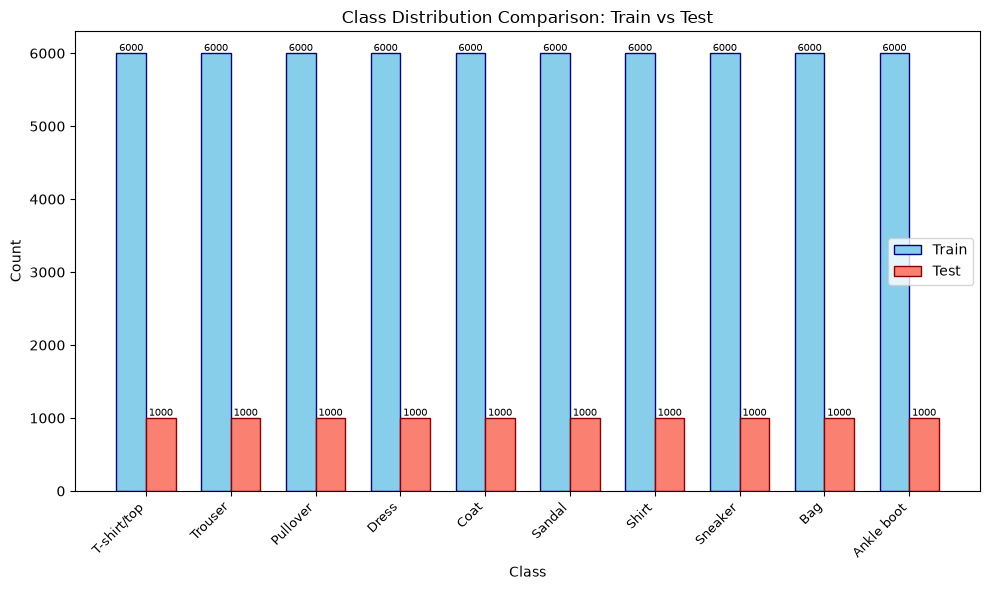


Train set size: 60000  |  Test set size: 10000
Class proportions (Train):  ['10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%']
Class proportions (Test):   ['10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%', '10.0%']


In [8]:
from src.vis_utils import plot_class_distribution_comparison
plot_class_distribution_comparison(
    train_dataset, test_dataset, class_names,
    save_path=os.path.join(ERROR_ANALYSIS_DIR, 'class_distribution_comparison.png')
)

## 4. CNN Architecture (No Attention)

The model is a **pure convolutional network** built exclusively from:
- `nn.Conv2d` — convolutional layers
- `nn.BatchNorm2d` — normalisation
- `nn.ReLU` — activation
- `nn.MaxPool2d` — spatial downsampling
- `nn.Dropout2d` / `nn.Dropout` — regularisation
- `nn.AdaptiveAvgPool2d` — global pooling
- `nn.Flatten` + `nn.Linear` — classifier head

No attention mechanisms (SE, CBAM, self-attention, Transformer) are used anywhere.

In [9]:
class DiagnosticCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        # Block 1: 1 -> 32
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(2)  # 28 -> 14

        # Block 2: 32 -> 64
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(64)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2)  # 14 -> 7

        # Block 3: 64 -> 128
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2)  # 7 -> 3

        # Global average pooling + classifier
        self.global_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, num_classes)

        self.relu = nn.ReLU(inplace=True)

    def get_features(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)
        x = self.relu(self.bn3(self.conv3(x)))
        x = self.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)
        x = self.relu(self.bn5(self.conv5(x)))
        x = self.pool3(x)
        x = self.global_pool(x)
        return x.view(x.size(0), -1)

    def forward(self, x):
        x = self.get_features(x)
        x = self.dropout(x)
        x = self.fc(x)
        return x


model = DiagnosticCNN().to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f"DiagnosticCNN parameters: {total_params:,}")

# Quick forward check
dummy = torch.randn(2, 1, 28, 28).to(device)
out = model(dummy)
print(f"Output shape: {out.shape}  (expected: [2, 10])")

# Verify no attention modules
for name, module in model.named_modules():
    cls_name = module.__class__.__name__
    if 'Attention' in cls_name or 'SE' in cls_name or 'CBAM' in cls_name or 'Transformer' in cls_name:
        raise RuntimeError(f"Attention mechanism found: {name} -> {cls_name}")
print("Validation passed: model contains only CNN layers (no attention).")

DiagnosticCNN parameters: 140,778
Output shape: torch.Size([2, 10])  (expected: [2, 10])
Validation passed: model contains only CNN layers (no attention).


## 5. Train the CNN

Training for 15 epochs with CrossEntropyLoss + Adam.

In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 15

train_losses = []
model.train()
for epoch in range(num_epochs):
    epoch_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    train_losses.append(epoch_loss)
    print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {epoch_loss:.4f}')

# Save training losses
with open(os.path.join(ERROR_ANALYSIS_DIR, 'train_losses.txt'), 'w') as f:
    for loss in train_losses:
        f.write(f'{loss}\n')
print(f"Training losses saved to {ERROR_ANALYSIS_DIR}/train_losses.txt")

Epoch [1/15], Loss: 0.4604
Epoch [2/15], Loss: 0.2953
Epoch [3/15], Loss: 0.2531
Epoch [4/15], Loss: 0.2247
Epoch [5/15], Loss: 0.2081
Epoch [6/15], Loss: 0.1887
Epoch [7/15], Loss: 0.1758
Epoch [8/15], Loss: 0.1635
Epoch [9/15], Loss: 0.1494
Epoch [10/15], Loss: 0.1413
Epoch [11/15], Loss: 0.1279
Epoch [12/15], Loss: 0.1191
Epoch [13/15], Loss: 0.1089
Epoch [14/15], Loss: 0.1016
Epoch [15/15], Loss: 0.0933
Training losses saved to ../outputs/error_analysis/train_losses.txt


## 6. Comprehensive Evaluation

All metrics are saved as raw numerical files in `outputs/error_analysis/`.

In [11]:
# --- 6a. Accuracy, Per-Class Metrics, Confusion Matrix ---
accuracy, cm, per_class = evaluate_detailed(model, test_loader, device, class_names, model_name='CNN')

# Save raw confusion matrix
cm_np = cm.cpu().numpy()
with open(os.path.join(ERROR_ANALYSIS_DIR, 'confusion_matrix.txt'), 'w') as f:
    header = f'{"":>15}'
    for name in class_names:
        header += f'{name:>15}'
    f.write(header + '\n')
    for i in range(len(class_names)):
        row = f'{class_names[i]:>15}'
        for j in range(len(class_names)):
            row += f'{cm_np[i, j]:>15}'
        f.write(row + '\n')
print("Confusion matrix saved.")

# --- 6b. ROC-AUC and PR-AUC ---
probas, labels = get_all_probas_and_labels(model, test_loader, device, 10)
roc_scores = compute_roc_auc_scores(probas, labels, model_name='CNN')
pr_scores = compute_pr_auc_scores(probas, labels, model_name='CNN')

# Save consolidated metrics file
with open(os.path.join(ERROR_ANALYSIS_DIR, 'metrics_summary.txt'), 'w') as f:
    f.write(f'Test Accuracy (percentage): {accuracy:.2f}\n')
    f.write(f'Test Accuracy (fraction): {accuracy / 100:.4f}\n\n')
    f.write(f'Macro ROC-AUC: {roc_scores["macro"]:.6f}\n')
    f.write(f'Macro PR-AUC:  {pr_scores["macro"]:.6f}\n\n')
    f.write(f'{"Class":<15} {"ROC-AUC":>10} {"PR-AUC":>10} {"TPR":>10} {"Precision":>10}\n')
    f.write(f'{"-"*55}\n')
    for i, name in enumerate(class_names):
        tpr = per_class[name]['TPR']
        prec = per_class[name]['Precision']
        f.write(f'{name:<15} {roc_scores[f"class_{i}"]:>10.4f} {pr_scores[f"class_{i}"]:>10.4f} {tpr:>10.4f} {prec:>10.4f}\n')
print("Metrics summary saved.")

# --- 6c. Save model weights ---
save_model(model, os.path.join(ERROR_ANALYSIS_DIR, 'diagnostic_cnn.pth'))

print(f"\nAll metrics saved to {ERROR_ANALYSIS_DIR}/")

  Test Accuracy: 92.50%
  Class           TPR(Recall)        FPR  Precision
  ---------------------------------------------
  T-shirt/top         0.8370     0.0103     0.9000
  Trouser             0.9880     0.0011     0.9900
  Pullover            0.8900     0.0114     0.8963
  Dress               0.9070     0.0064     0.9399
  Coat                0.8700     0.0071     0.9315
  Sandal              0.9780     0.0011     0.9899
  Shirt               0.8470     0.0361     0.7227
  Sneaker             0.9910     0.0063     0.9456
  Bag                 0.9860     0.0020     0.9821
  Ankle boot          0.9560     0.0013     0.9876
Confusion matrix saved.
Metrics summary saved.
Model saved to ../outputs/error_analysis\diagnostic_cnn.pth

All metrics saved to ../outputs/error_analysis/


## 7. Per-Class Mean Images

Compute and visualise the average pixel intensity per class to understand the prototypical silhouette of each class.

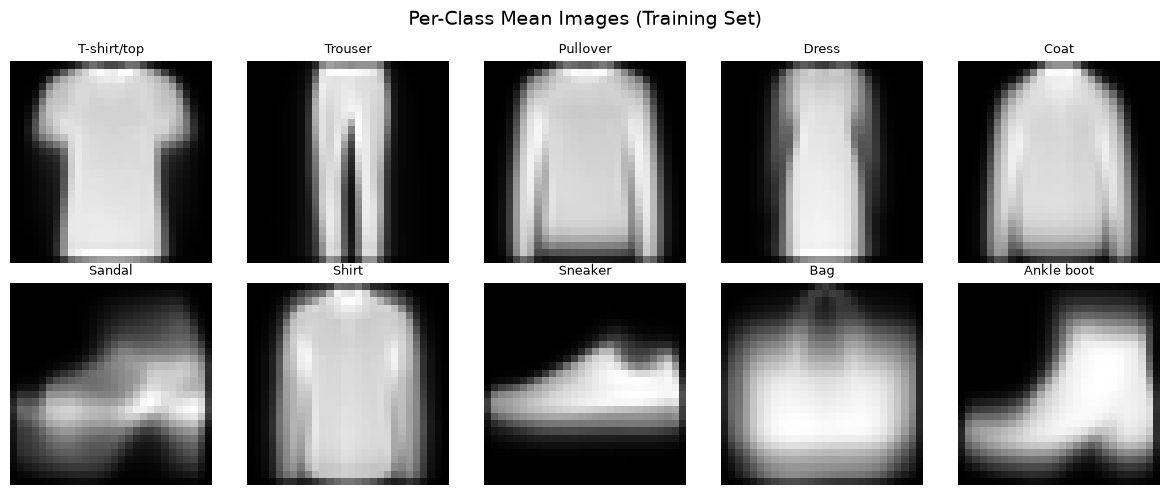

Class mean images saved.


In [12]:
# Compute per-class mean images
n_classes = len(class_names)
class_means = np.zeros((n_classes, 28, 28))
class_counts = np.zeros(n_classes)

for i in range(len(train_dataset)):
    img, label = train_dataset[i]
    class_means[label] += img.squeeze().numpy()
    class_counts[label] += 1

for c in range(n_classes):
    class_means[c] /= class_counts[c]

# Plot all 10 mean images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c in range(n_classes):
    ax = axes[c // 5, c % 5]
    ax.imshow(class_means[c], cmap='gray')
    ax.set_title(class_names[c], fontsize=9)
    ax.axis('off')
plt.suptitle('Per-Class Mean Images (Training Set)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ERROR_ANALYSIS_DIR, 'per_class_means.png'), dpi=150)
plt.show()

# Save mean pixel values as raw data
with open(os.path.join(ERROR_ANALYSIS_DIR, 'class_mean_pixels.txt'), 'w') as f:
    for c in range(n_classes):
        f.write(f'{class_names[c]}: mean={class_means[c].mean():.4f}, '
                f'std={class_means[c].std():.4f}, '
                f'min={class_means[c].min():.4f}, '
                f'max={class_means[c].max():.4f}\n')
print("Class mean images saved.")

## 8. Between-Class Difference Maps

For frequently confused pairs, compute the pixel-wise difference image. Positive regions indicate pixels that are brighter in class A than class B — these are the discriminative regions the model should learn.

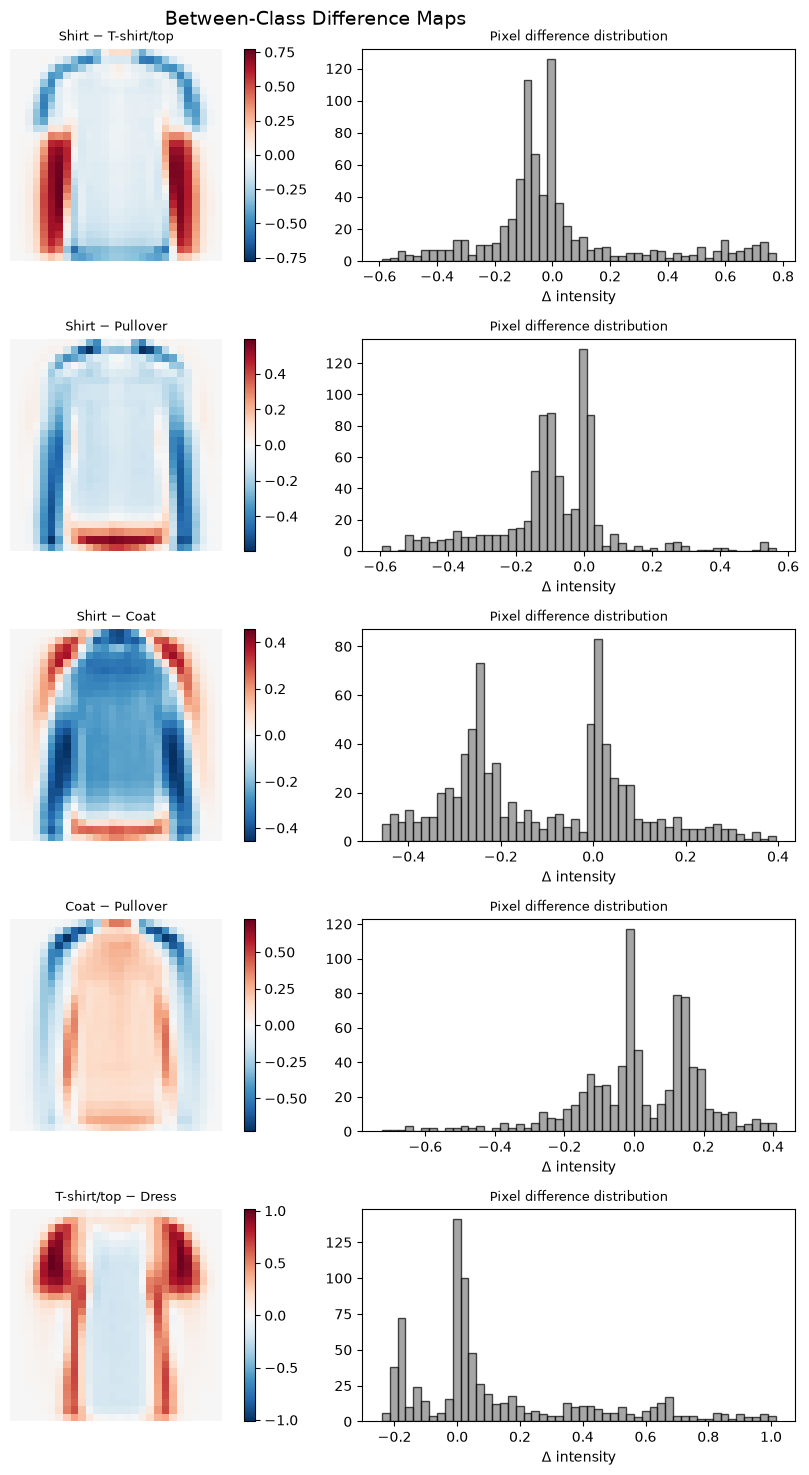

Class difference maps saved.


In [13]:
confused_pairs = [
    ('Shirt', 'T-shirt/top'),
    ('Shirt', 'Pullover'),
    ('Shirt', 'Coat'),
    ('Coat', 'Pullover'),
    ('T-shirt/top', 'Dress'),
]

fig, axes = plt.subplots(len(confused_pairs), 2, figsize=(10, 3 * len(confused_pairs)))
for idx, (c1, c2) in enumerate(confused_pairs):
    i1 = class_names.index(c1)
    i2 = class_names.index(c2)
    diff = class_means[i1] - class_means[i2]
    vmax = max(abs(diff.min()), abs(diff.max()))

    ax1 = axes[idx, 0]
    im = ax1.imshow(diff, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax1.set_title(f'{c1} − {c2}', fontsize=9)
    ax1.axis('off')
    plt.colorbar(im, ax=ax1, fraction=0.046)

    ax2 = axes[idx, 1]
    ax2.hist(diff.flatten(), bins=50, color='gray', edgecolor='black', alpha=0.7)
    ax2.set_title(f'Pixel difference distribution', fontsize=9)
    ax2.set_xlabel('Δ intensity')

plt.suptitle('Between-Class Difference Maps', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ERROR_ANALYSIS_DIR, 'class_difference_maps.png'), dpi=150)
plt.show()

# Save difference statistics as raw data
with open(os.path.join(ERROR_ANALYSIS_DIR, 'class_differences.txt'), 'w') as f:
    f.write(f'{"Pair":<25} {"Mean Δ":>10} {"Std Δ":>10} {"Max Δ":>10} {"|Δ|>0.1":>10}\n')
    f.write('-' * 65 + '\n')
    for c1, c2 in confused_pairs:
        i1 = class_names.index(c1)
        i2 = class_names.index(c2)
        diff = class_means[i1] - class_means[i2]
        frac_significant = (np.abs(diff) > 0.1).mean()
        f.write(f'{c1} vs {c2:<10} {diff.mean():>10.4f} {diff.std():>10.4f} {np.abs(diff).max():>10.4f} {frac_significant:>9.1%}\n')
print("Class difference maps saved.")

## 9. Per-Pixel Variance Map

High intra-class variance indicates regions where samples of the same class differ substantially — these are ambiguous areas where the model struggles to find consistent features.

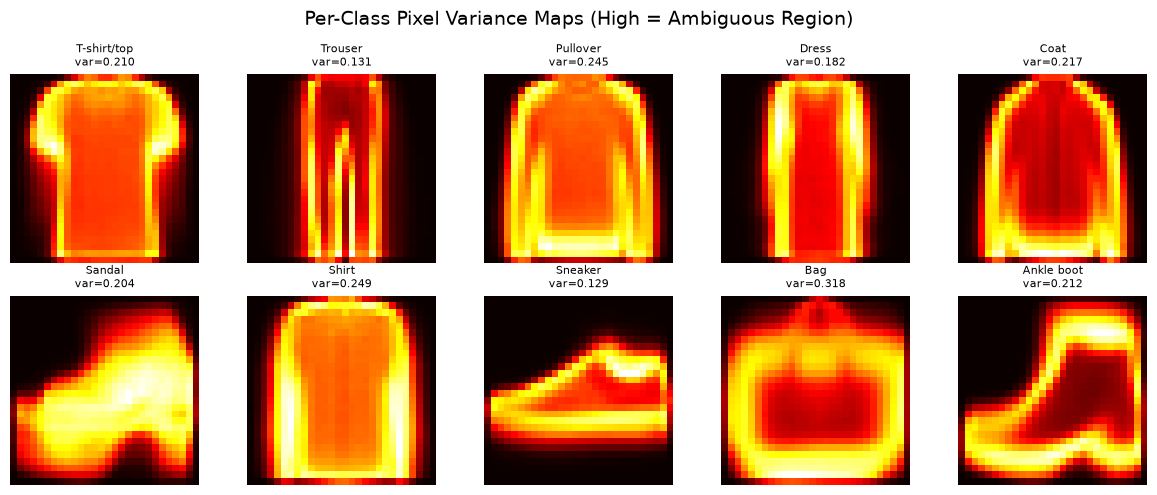

Class variance maps saved.


In [14]:
# Compute per-pixel variance per class
class_vars = np.zeros((n_classes, 28, 28))
class_counts = np.zeros(n_classes)

for i in range(len(train_dataset)):
    img, label = train_dataset[i]
    diff = img.squeeze().numpy() - class_means[label]
    class_vars[label] += diff ** 2
    class_counts[label] += 1

for c in range(n_classes):
    class_vars[c] /= class_counts[c]

# Plot variance maps
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c in range(n_classes):
    ax = axes[c // 5, c % 5]
    ax.imshow(class_vars[c], cmap='hot')
    ax.set_title(f'{class_names[c]}\nvar={class_vars[c].mean():.3f}', fontsize=8)
    ax.axis('off')
plt.suptitle('Per-Class Pixel Variance Maps (High = Ambiguous Region)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ERROR_ANALYSIS_DIR, 'per_class_variance.png'), dpi=150)
plt.show()

# Save variance statistics as raw data
with open(os.path.join(ERROR_ANALYSIS_DIR, 'class_variance.txt'), 'w') as f:
    f.write(f'{"Class":<15} {"Mean Var":>10} {"Max Var":>10} {"Top-5 Var Region":>30}\n')
    f.write('-' * 65 + '\n')
    for c in range(n_classes):
        var_map = class_vars[c]
        max_idx = np.unravel_index(np.argmax(var_map), var_map.shape)
        f.write(f'{class_names[c]:<15} {var_map.mean():>10.4f} {var_map.max():>10.4f} {str(max_idx):>30}\n')
print("Class variance maps saved.")

## 10. Confidence Analysis

Analyse the distribution of prediction confidence (max softmax probability) for correct vs incorrect predictions. Low-confidence errors sit near the decision boundary; high-confidence errors suggest label ambiguity.

Confidence analysis saved.


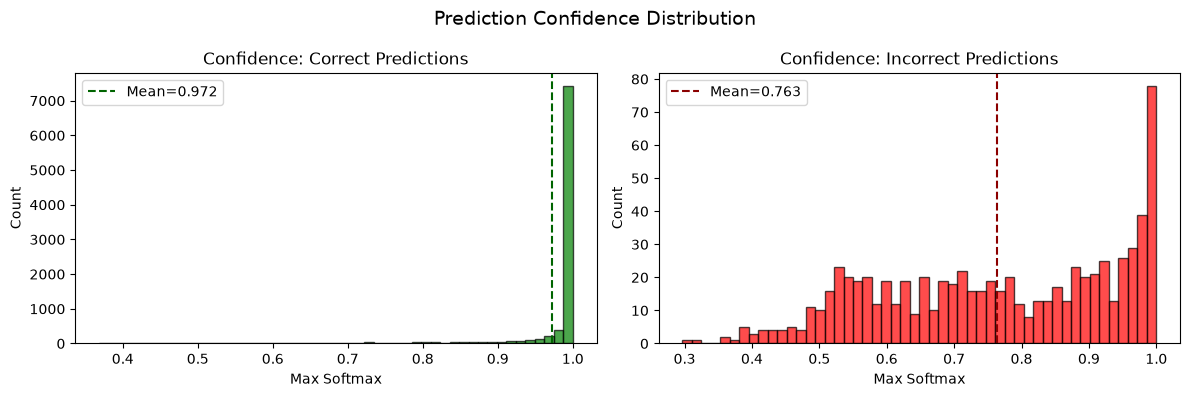

In [15]:
model.eval()
all_probas_list = []
all_labels_list = []
all_preds_list = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probas = torch.softmax(outputs, dim=1)
        _, preds = torch.max(probas, 1)
        all_probas_list.append(probas.cpu())
        all_labels_list.append(labels)
        all_preds_list.append(preds.cpu())

all_probas = torch.cat(all_probas_list).numpy()
all_labels = torch.cat(all_labels_list).numpy()
all_preds = torch.cat(all_preds_list).numpy()

max_confs = np.max(all_probas, axis=1)
correct_mask = all_preds == all_labels
error_mask = ~correct_mask

# Per-class confidence breakdown
with open(os.path.join(ERROR_ANALYSIS_DIR, 'confidence_analysis.txt'), 'w') as f:
    f.write(f'{"Class":<15} {"Mean Conf (Correct)":>20} {"Mean Conf (Error)":>19} {"Error Rate":>12}\n')
    f.write('-' * 66 + '\n')
    for c in range(n_classes):
        c_mask = all_labels == c
        correct_c = correct_mask & c_mask
        error_c = error_mask & c_mask
        mean_correct_conf = max_confs[correct_c].mean() if correct_c.sum() > 0 else 0
        mean_error_conf = max_confs[error_c].mean() if error_c.sum() > 0 else 0
        err_rate = error_c.sum() / c_mask.sum()
        f.write(f'{class_names[c]:<15} {mean_correct_conf:>19.4f} {mean_error_conf:>18.4f} {err_rate:>11.2%}\n')
    f.write('-' * 66 + '\n')
    f.write(f'{"Overall":<15} {max_confs[correct_mask].mean():>19.4f} {max_confs[error_mask].mean():>18.4f} {error_mask.mean():>11.2%}\n')

print("Confidence analysis saved.")

# Plot confidence histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(max_confs[correct_mask], bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0].axvline(max_confs[correct_mask].mean(), color='darkgreen', linestyle='--', label=f'Mean={max_confs[correct_mask].mean():.3f}')
axes[0].set_title('Confidence: Correct Predictions')
axes[0].set_xlabel('Max Softmax')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(max_confs[error_mask], bins=50, alpha=0.7, color='red', edgecolor='black')
axes[1].axvline(max_confs[error_mask].mean(), color='darkred', linestyle='--', label=f'Mean={max_confs[error_mask].mean():.3f}')
axes[1].set_title('Confidence: Incorrect Predictions')
axes[1].set_xlabel('Max Softmax')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Prediction Confidence Distribution', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(ERROR_ANALYSIS_DIR, 'confidence_distribution.png'), dpi=150)
plt.show()

## 11. Misclassification Pattern Analysis

For each confused pair, compute how many errors occur and the mean confidence of those errors. This identifies both high-volume and high-certainty confusion patterns.

In [16]:
# Build confusion matrix from raw predictions
confusion = np.zeros((n_classes, n_classes), dtype=int)
for t, p in zip(all_labels, all_preds):
    confusion[int(t), int(p)] += 1

# For each true class, find the top-2 most confused predicted classes
with open(os.path.join(ERROR_ANALYSIS_DIR, 'misclassification_analysis.txt'), 'w') as f:
    f.write('Misclassification Analysis\n')
    f.write('=' * 70 + '\n\n')
    for c in range(n_classes):
        true_name = class_names[c]
        total_errors = confusion[c].sum() - confusion[c, c]
        f.write(f'True class: {true_name}  (total errors: {total_errors})\n')
        f.write('-' * 50 + '\n')
        # Sort by error count descending
        error_indices = np.argsort(-confusion[c])
        for p in error_indices:
            if p == c or confusion[c, p] == 0:
                continue
            pred_name = class_names[p]
            err_count = confusion[c, p]
            # Mean confidence of these errors
            err_mask = (all_labels == c) & (all_preds == p)
            mean_conf = max_confs[err_mask].mean() if err_mask.sum() > 0 else 0
            f.write(f'  → predicted as {pred_name:<15} count={err_count:>4}  mean_conf={mean_conf:.4f}\n')
        f.write('\n')

print("Misclassification analysis saved.")

Misclassification analysis saved.


## 12. Summary Report

All diagnostic files have been saved to `outputs/error_analysis/`. The following files are available:

| File | Contents |
|------|----------|
| `train_losses.txt` | Per-epoch training loss values |
| `metrics_summary.txt` | Accuracy, per-class ROC-AUC, PR-AUC, TPR, Precision |
| `confusion_matrix.txt` | Raw confusion matrix (rows=true, cols=predicted) |
| `class_mean_pixels.txt` | Per-class mean, std, min, max pixel intensities |
| `class_variance.txt` | Per-class pixel variance statistics |
| `class_differences.txt` | Between-class difference map statistics for confused pairs |
| `confidence_analysis.txt` | Mean confidence for correct vs incorrect predictions per class |
| `misclassification_analysis.txt` | Detailed per-class error breakdown with confidence |
| `diagnostic_cnn.pth` | Trained model weights |
| `*.png` | Plots for all of the above |

**Key diagnostic questions these files answer:**

1. *Which classes have near-identical mean images?* → Look at `class_differences.txt` — small Δ mean indicates silhouette overlap.
2. *Which classes have high intra-class variance?* → Look at `class_variance.txt` — high variance = samples look very different from each other.
3. *Are errors high or low confidence?* → Look at `confidence_analysis.txt` — if error confidence > 0.9, samples may be genuinely ambiguous.
4. *What is the dominant confusion pair?* → Look at `misclassification_analysis.txt` — identifies which pair needs targeted augmentation.